# DataPreparation.ipynb
## 15-288 D2

---
## D2.1: Data Acquisition

The dataset was scraped from [Objaverse](https://objaverse.allenai.org/) using a custom script (`scripts/fruit_scraping.py`). It searches annotations by fruit name and botanical synonyms, filters noise via a blacklist and confirmation tags, then downloads and renames the files by class label. After scraping, the dataset was manually reviewed and filtered using a custom-built web app (`scripts/model_sorter.html`) that displayed each 3D model and allowed accepting or discarding it, producing the final curated set.

**Dataset:** [Google Drive Link](https://drive.google.com/file/d/16ezgCrRuOz9kJHVpb96ibwiPEzSIU428/view?usp=sharing)

## D2.2: Data Analysis

In [26]:
import os
import re
import json
import struct
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [ ]:
FRUIT_DIR = Path('../data/fruit_scraped')  # download from the Drive link in D2.1 and place here


def extract_label(filename: str) -> str:
    stem = Path(filename).stem
    return re.sub(r'\d+$', '', stem)


def build_dataframe(directory: Path) -> pd.DataFrame:
    rows = []
    for fname in sorted(os.listdir(directory)):
        if not fname.endswith('.glb'):
            continue
        path = directory / fname
        rows.append({
            'filename':   fname,
            'filepath':   str(path),
            'label':      extract_label(fname),
            'size_bytes': path.stat().st_size,
            'size_mb':    path.stat().st_size / 1e6,
        })
    return pd.DataFrame(rows)


fruit_df = build_dataframe(FRUIT_DIR)

MIN_SAMPLES  = 11
class_counts = fruit_df['label'].value_counts()
keep_classes = class_counts[class_counts >= MIN_SAMPLES].index.tolist()
dropped      = sorted(class_counts[class_counts < MIN_SAMPLES].index.tolist())
fruit_df     = fruit_df[fruit_df['label'].isin(keep_classes)].reset_index(drop=True)

print(f'Fruit dataset — {len(fruit_df)} samples  |  {fruit_df["label"].nunique()} classes')
print(f'Dropped ({len(dropped)} classes with < {MIN_SAMPLES} samples): {dropped}')

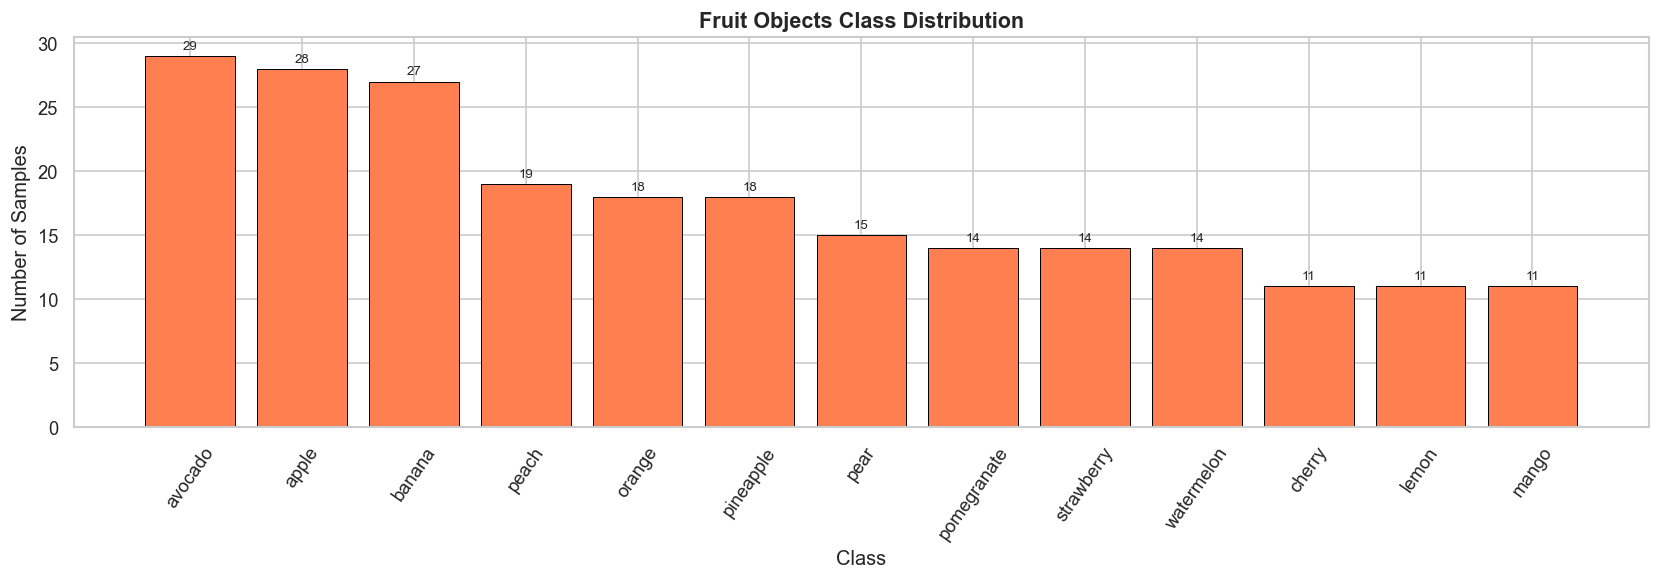

In [28]:
counts = fruit_df['label'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(counts.index, counts.values, color='coral', edgecolor='black', linewidth=0.6)
ax.set_title('Fruit Objects Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

In [29]:
print(fruit_df['label'].value_counts().to_string())
print(f"\nTotal samples : {len(fruit_df)}")
print(f"Total classes : {fruit_df['label'].nunique()}")
print(f"Imbalance ratio (max/min): {fruit_df['label'].value_counts().max() / fruit_df['label'].value_counts().min():.1f}x")

label
avocado        29
apple          28
banana         27
peach          19
orange         18
pineapple      18
pear           15
pomegranate    14
strawberry     14
watermelon     14
cherry         11
lemon          11
mango          11

Total samples : 229
Total classes : 13
Imbalance ratio (max/min): 2.6x


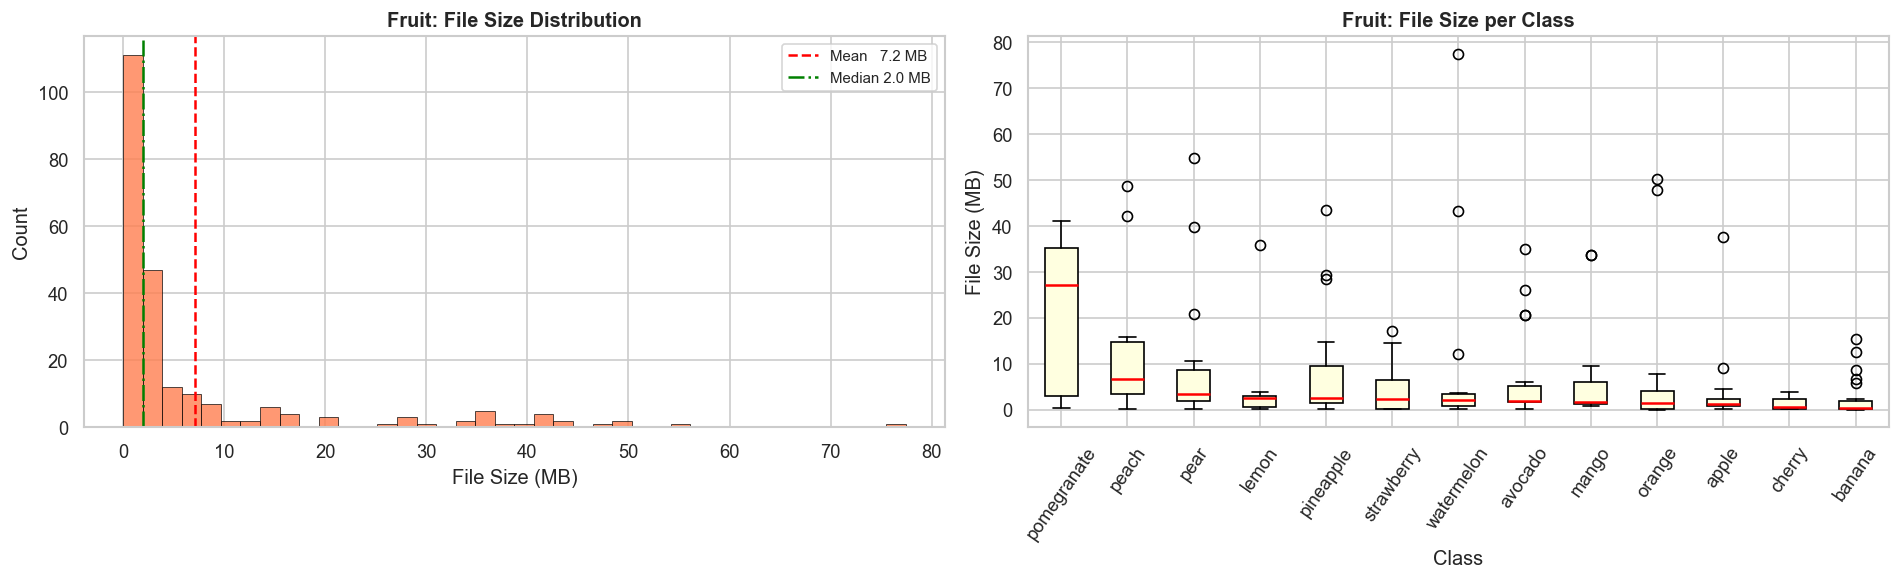

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall histogram
axes[0].hist(fruit_df['size_mb'], bins=40, color='coral', edgecolor='black', linewidth=0.5, alpha=0.8)
mean_v, med_v = fruit_df['size_mb'].mean(), fruit_df['size_mb'].median()
axes[0].axvline(mean_v, color='red',   linestyle='--', linewidth=1.5, label=f'Mean   {mean_v:.1f} MB')
axes[0].axvline(med_v,  color='green', linestyle='-.', linewidth=1.5, label=f'Median {med_v:.1f} MB')
axes[0].set_title('Fruit: File Size Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('File Size (MB)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Boxplot per class
order  = fruit_df.groupby('label')['size_mb'].median().sort_values(ascending=False).index.tolist()
groups = [fruit_df[fruit_df['label'] == lbl]['size_mb'].values for lbl in order]
axes[1].boxplot(groups, patch_artist=True, labels=order,
                boxprops=dict(facecolor='lightyellow', color='black'),
                medianprops=dict(color='red', linewidth=1.5))
axes[1].set_title('Fruit: File Size per Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('File Size (MB)')
axes[1].tick_params(axis='x', rotation=55)

plt.tight_layout()
plt.savefig('file_size_distributions.png', bbox_inches='tight')
plt.show()

In [31]:
print(fruit_df.groupby('label')['size_mb']
      .agg(['count', 'mean', 'std', 'min', 'max'])
      .round(2)
      .sort_values('mean', ascending=False)
      .to_string())

             count   mean    std   min    max
label                                        
pomegranate     14  21.95  16.96  0.30  41.01
peach           19  11.10  13.17  0.02  48.58
watermelon      14  10.78  22.23  0.10  77.41
pear            15  10.39  16.09  0.12  54.80
pineapple       18   8.75  12.52  0.07  43.49
mango           11   8.07  12.89  0.78  33.67
orange          18   7.05  15.41  0.00  50.14
avocado         29   5.46   8.62  0.02  35.05
strawberry      14   4.93   6.07  0.04  17.17
lemon           11   4.85  10.35  0.10  35.81
apple           28   3.01   7.00  0.01  37.49
banana          27   2.29   4.03  0.00  15.46
cherry          11   1.28   1.37  0.03   3.85


In [32]:
GLB_MAGIC   = 0x46546C67  # 'glTF' in little-endian
JSON_CHUNK  = 0x4E4F534A  # 'JSON'


def parse_glb_stats(filepath):
    try:
        with open(filepath, 'rb') as f:
            magic, version, _ = struct.unpack('<III', f.read(12))
            if magic != GLB_MAGIC:
                return None
            chunk_len, chunk_type = struct.unpack('<II', f.read(8))
            if chunk_type != JSON_CHUNK:
                return None
            gltf = json.loads(f.read(chunk_len).decode('utf-8', errors='replace'))

        accessors  = gltf.get('accessors', [])
        meshes     = gltf.get('meshes', [])
        total_verts = 0
        total_faces = 0
        for mesh in meshes:
            for prim in mesh.get('primitives', []):
                pos_idx = prim.get('attributes', {}).get('POSITION')
                if pos_idx is not None:
                    total_verts += accessors[pos_idx].get('count', 0)
                idx = prim.get('indices')
                if idx is not None:
                    total_faces += accessors[idx].get('count', 0) // 3

        return {
            'num_meshes':    len(meshes),
            'num_materials': len(gltf.get('materials', [])),
            'num_textures':  len(gltf.get('textures', [])),
            'num_nodes':     len(gltf.get('nodes', [])),
            'vertex_count':  total_verts,
            'face_count':    total_faces,
        }
    except Exception:
        return None

In [33]:
SAMPLE_PER_CLASS = 15

def sample_and_parse(df: pd.DataFrame, n: int = SAMPLE_PER_CLASS) -> pd.DataFrame:
    sampled = (
        df.groupby('label', group_keys=False)
          .apply(lambda g: g.sample(min(n, len(g)), random_state=42))
          .reset_index(drop=True)
    )
    stats_list = []
    for _, row in sampled.iterrows():
        s = parse_glb_stats(row['filepath'])
        if s:
            stats_list.append({**row.to_dict(), **s})
    return pd.DataFrame(stats_list)


print('Parsing fruit GLB files (sample)…')
fruit_mesh = sample_and_parse(fruit_df)
print(f'  Parsed {len(fruit_mesh)} files')

Parsing fruit GLB files (sample)…
  Parsed 180 files


In [34]:
mesh_cols = ['vertex_count', 'face_count', 'num_materials', 'num_textures', 'num_nodes']

print(fruit_mesh[mesh_cols].describe().round(0).to_string())

       vertex_count  face_count  num_materials  num_textures  num_nodes
count         180.0       180.0          180.0         180.0      180.0
mean       126620.0    159308.0            2.0           2.0       13.0
std        281546.0    313763.0            4.0           2.0       36.0
min            81.0        48.0            1.0           0.0        3.0
25%          1268.0      1942.0            1.0           0.0        5.0
50%          8454.0     13658.0            1.0           1.0        6.0
75%        108710.0    160230.0            2.0           2.0       11.0
max       2036176.0   1306179.0           50.0          12.0      414.0


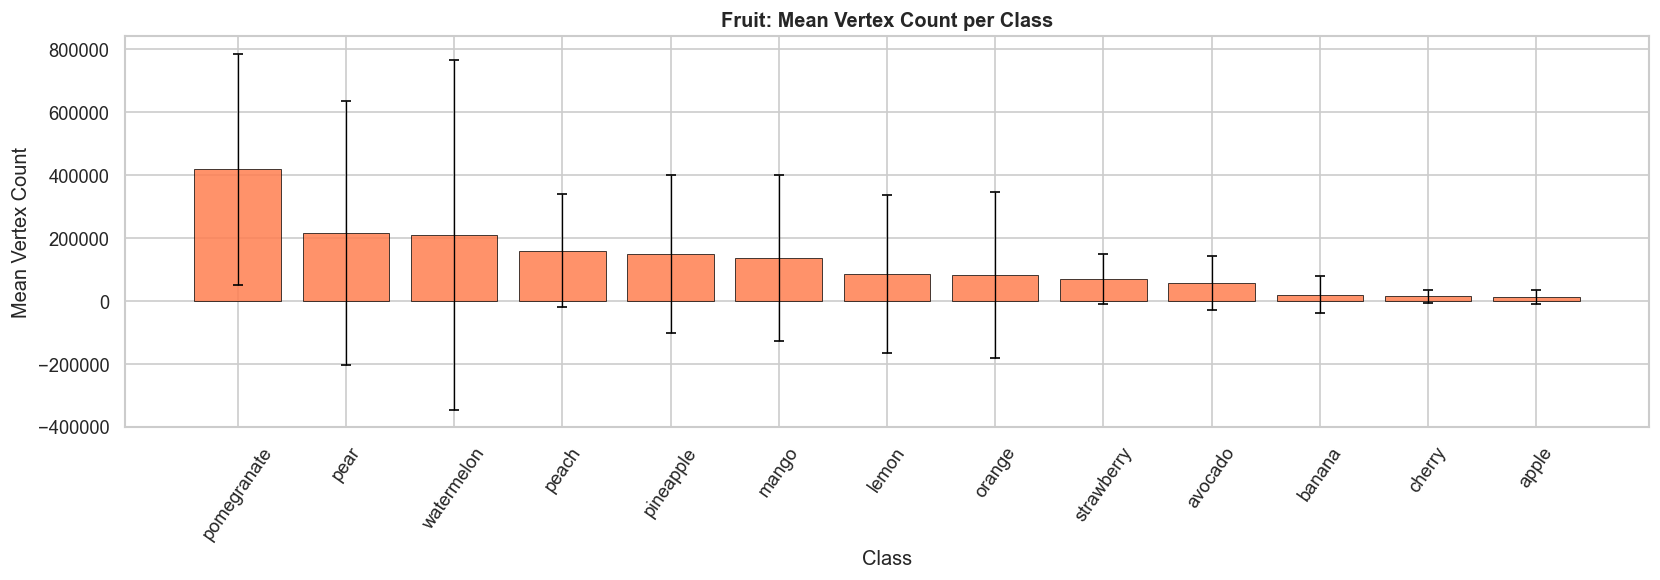

In [35]:
means = fruit_mesh.groupby('label')['vertex_count'].mean().sort_values(ascending=False)
stds  = fruit_mesh.groupby('label')['vertex_count'].std().reindex(means.index).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(means.index, means.values, yerr=stds.values, capsize=3,
       color='coral', edgecolor='black', linewidth=0.5, alpha=0.85,
       error_kw=dict(elinewidth=0.8, ecolor='black'))
ax.set_title('Fruit: Mean Vertex Count per Class', fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Mean Vertex Count')
ax.tick_params(axis='x', rotation=55)

plt.tight_layout()
plt.savefig('vertex_count_per_class.png', bbox_inches='tight')
plt.show()

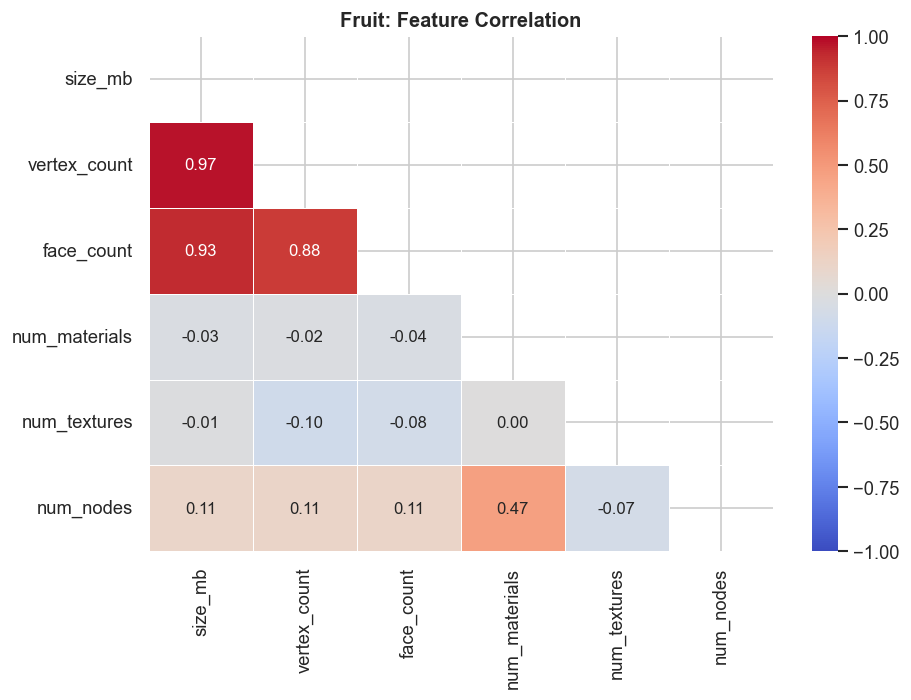

In [18]:
corr = fruit_mesh[['size_mb', 'vertex_count', 'face_count',
                   'num_materials', 'num_textures', 'num_nodes']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Fruit: Feature Correlation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()

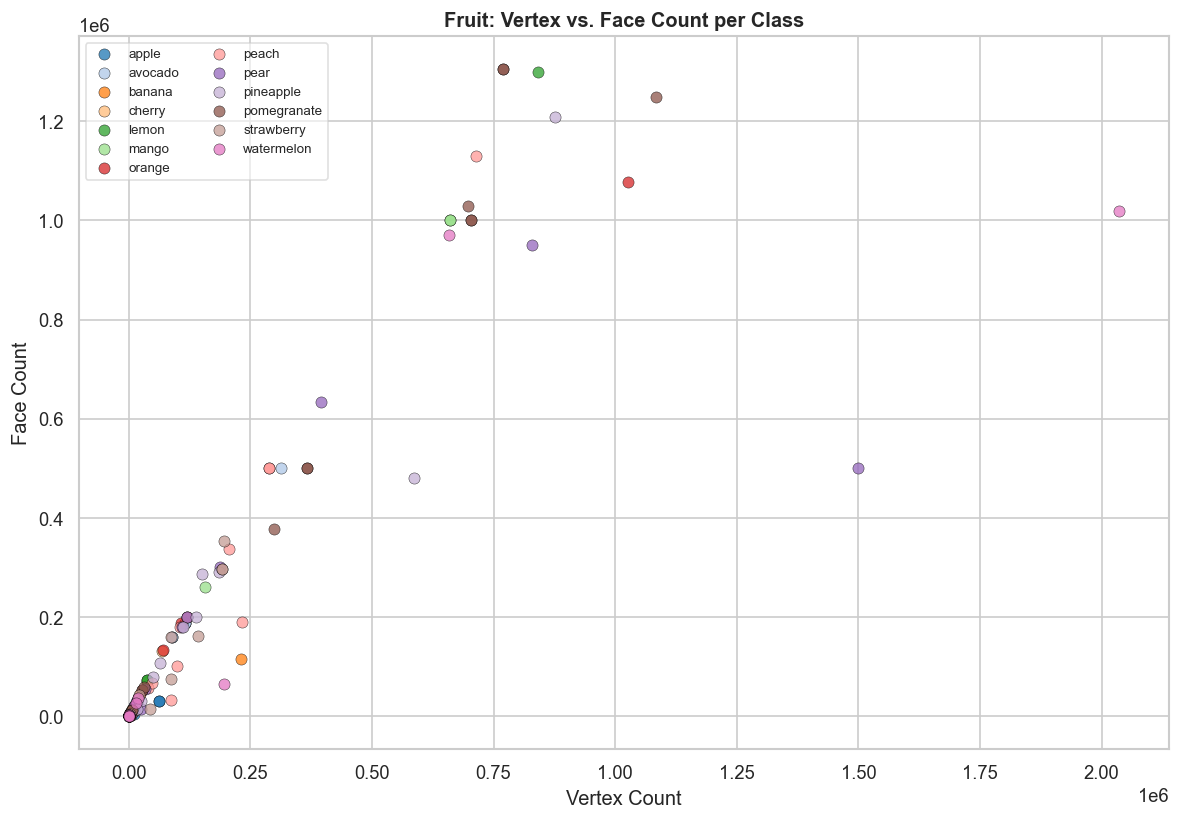

In [36]:
classes = fruit_mesh['label'].unique()
palette = sns.color_palette('tab20', n_colors=len(classes))

fig, ax = plt.subplots(figsize=(10, 7))
for cls, col in zip(classes, palette):
    sub = fruit_mesh[fruit_mesh['label'] == cls]
    ax.scatter(sub['vertex_count'], sub['face_count'],
               label=cls, color=col, alpha=0.75, s=45, edgecolors='black', linewidths=0.3)

ax.set_xlabel('Vertex Count')
ax.set_ylabel('Face Count')
ax.set_title('Fruit: Vertex vs. Face Count per Class', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper left', framealpha=0.6)

plt.tight_layout()
plt.savefig('vertex_face_scatter.png', bbox_inches='tight')
plt.show()

In [38]:
print(f'Total samples : {len(fruit_df)}')
print(f'Total classes : {fruit_df["label"].nunique()}')
print(f'Min per class : {fruit_df["label"].value_counts().min()}')
print(f'Max per class : {fruit_df["label"].value_counts().max()}')
print(f'Mean per class: {fruit_df["label"].value_counts().mean():.1f}')
print(f'\nTotal size on disk: {fruit_df["size_mb"].sum():.1f} MB')

Total samples : 229
Total classes : 13
Min per class : 11
Max per class : 29
Mean per class: 17.6

Total size on disk: 1639.2 MB


---
## D2.3: Data Wrangling

The raw files downloaded from Objaverse are heterogeneous — formats include GLB, FBX, STL, PLY, and OBJ, with varying mesh quality (holes, non-manifold geometry, inconsistent scale/orientation, multiple disjoint sub-meshes). The wrangling pipeline standardizes them into clean, normalized OBJ meshes ready for 3D ML.

### Pipeline

**Step 1 — Format Conversion** (`scripts/3d_file_to_obj.py`)

Uses Blender's headless Python API (`bpy`) to:
- Import each file with its format-specific importer
- Join all sub-meshes into a single unified mesh object
- Export as `.obj`

**Step 2 — Mesh Cleanup** (`scripts/mesh_cleanup.py`)

Processes each converted OBJ through:
1. **Normalize**: Center at origin and scale uniformly to fit within a 2×2×2 unit cube — ensures consistent scale across all models
2. **Voxel Remesh** (size = 0.01): Re-tessellates the surface at uniform resolution, closing holes and producing a watertight topology
3. **Shrinkwrap**: Snaps the remeshed surface back onto the original geometry to recover fine detail lost during voxelization
4. **Boolean Intersection**: Clips the mesh against a 2×2×2 cube to enforce a hard manifold boundary
5. **Recalculate Normals**: Ensures all face normals point outward
6. Export final clean `.obj` → `data/fruit_remeshed`

**Step 3 — Low-Poly Version** (`scripts/mesh_cleanup.py --voxel_size 0.05`)

Repeats the same cleanup pipeline with a coarser voxel size (0.05 vs 0.01), producing a simplified low-polygon mesh. This lower-resolution version is used as input for the GNN feature extractor in D2.4, where graph size must be tractable. Output → `data/fruit_low_poly`

### How to Run

Both scripts require [Blender](https://www.blender.org/download/) (4.2+) and must be run via its headless CLI.

> **Note:** `data/fruit` is a small example set included in the submission folder to demonstrate the pipeline. The full curated dataset (229 models) is available via the [Google Drive link](https://drive.google.com/file/d/16ezgCrRuOz9kJHVpb96ibwiPEzSIU428/view?usp=sharing) in D2.1. Download and point `--input` to that folder to process the real data.

**Step 1 — Convert to OBJ**
```bash
blender --background --python scripts/3d_file_to_obj.py -- \
  --input  data/fruit \
  --output data/fruit_objs
```

**Step 2 — Normalize and clean**
```bash
blender --background --python scripts/mesh_cleanup.py -- \
  --input  data/fruit_objs \
  --output data/fruit_remeshed
```

**Step 3 — Low-poly version (for GNN)**
```bash
blender --background --python scripts/mesh_cleanup.py -- \
  --input  data/fruit_objs \
  --output data/fruit_low_poly \
  --voxel_size 0.05
```

Both scripts process every file in the input directory and write results to the output directory.

---
## D2.4: Feature Extraction

The cleaned meshes are converted into model-ready input representations. Three formats are generated in parallel, each targeting a different 3D deep learning architecture:

**3D CNN — Voxel Grid** (`scripts/mesh_to_3D_cnn_input_feature.py`)

Voxelizes each mesh into a n×n×n binary occupancy grid. Each cell is 1 if occupied by geometry, 0 otherwise. Input: `data/fruit_remeshed` → Output: `data/fruit_voxels`

**PointNet — Point Cloud** (`scripts/mesh_to_pointnet_input_feature.py`)

Uniformly samples m points from the mesh surface. Each point carries XYZ coordinates. Input: `data/fruit_remeshed` → Output: `data/fruit_points`

**GNN — Mesh Graph** (`scripts/mesh_to_gnn_input_feature.py`)

Converts the mesh topology into a graph where vertices are nodes and mesh edges are graph edges. The low-poly meshes are used here to keep graph size tractable for training. Input: `data/fruit_low_poly` → Output: `data/fruit_graph`

**Verification** (`scripts/verify_model_input.py`)

Validates all three output directories and checks that a sample (by default it is '') is present across all formats and that array shapes are correct.

### How to Run

These scripts use standard Python (no Blender required).

**3D CNN — Voxelization**
```bash
python scripts/mesh_to_3D_cnn_input_feature.py \
  --input data/fruit_remeshed \
  --output data/fruit_voxels \
  --grid 32
```

**PointNet — Point Cloud**
```bash
python scripts/mesh_to_pointnet_input_feature.py \
  --input data/fruit_remeshed \
  --output data/fruit_points \
  --points 4096
```

**GNN — Mesh Graph**
```bash
python scripts/mesh_to_gnn_input_feature.py \
  --input data/fruit_low_poly \
  --output data/fruit_graph
```

**Verify outputs**
```bash
python scripts/verify_model_input.py
```